# XGBoost Probabilistic Forecasting with Daily Rolling Retraining (IESO Toronto)

This notebook implements the rolling retraining benchmark for IESO Toronto. Unlike the static benchmark, we retrain the XGBoost models at the start of each forecast day using a sliding 2-year historical window. This avoids model outdatedness and ensures absolute comparability against zero-shot foundation models (like Chronos-2) which are always given the immediate past context.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import holidays
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

HORIZON = 24

In [2]:
data_path = '../../data/ieso/ieso_toronto_covariate_2023_2025.csv'
df = pd.read_csv(data_path)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')
print(f"Loaded covariate data from {df.index.min()} to {df.index.max()}")

# Pre-compute rolling features on target energy
for w in [6, 12, 24]:
    df[f'load_roll_mean_{w}h'] = df['energy'].rolling(window=w).mean()
    df[f'load_roll_min_{w}h'] = df['energy'].rolling(window=w).min()
    df[f'load_roll_max_{w}h'] = df['energy'].rolling(window=w).max()
    df[f'load_roll_std_{w}h'] = df['energy'].rolling(window=w).std()

# Pre-compute rolling features on weather variables
for w in [3, 6, 12, 48, 72]:
    df[f'temp_roll_mean_{w}h'] = df['temp'].rolling(window=w).mean()
    df[f'apparent_temp_roll_mean_{w}h'] = df['apparent_temp'].rolling(window=w).mean()
    df[f'radiation_roll_mean_{w}h'] = df['radiation'].rolling(window=w).mean()

# Degree days and weather interactions
df['cdd'] = (df['temp'] - 18.33).clip(lower=0)
df['hdd'] = (18.33 - df['temp']).clip(lower=0)
df['apparent_cdd'] = (df['apparent_temp'] - 18.33).clip(lower=0)
df['temp_humidity_interaction'] = df['temp'] * df['humidity']

Loaded covariate data from 2023-01-01 00:00:00 to 2025-08-31 23:00:00


In [3]:
on_holidays = holidays.CA(prov='ON')

def get_calendar_features(dt_index):
    features = pd.DataFrame(index=dt_index)
    features['hour'] = dt_index.hour
    features['dayofweek'] = dt_index.dayofweek
    features['is_weekend'] = (dt_index.dayofweek >= 5).astype(int)
    features['month'] = dt_index.month
    features['is_holiday'] = pd.Series(dt_index).apply(lambda x: x in on_holidays).values.astype(int)
    return features

In [4]:
# Feature configurations
lag_cols = ['feat_origin', 'feat_origin_m1', 'feat_origin_m2', 
            'feat_24h_aligned', 'feat_48h_aligned', 'feat_168h_aligned']

roll_load_cols = []
for w in [6, 12, 24]:
    roll_load_cols.extend([f'load_roll_mean_{w}h', f'load_roll_min_{w}h', 
                           f'load_roll_max_{w}h', f'load_roll_std_{w}h'])

cal_cols = ['target_hour', 'target_dayofweek', 'target_is_weekend', 'target_month', 'target_is_holiday']

weather_cols = ['target_temp', 'target_humidity', 'target_dew_point', 'target_apparent_temp', 
                'target_wind_speed', 'target_cloud_cover', 'target_precip', 'target_radiation']

degree_cols = ['target_cdd', 'target_hdd', 'target_apparent_cdd']

roll_weather_cols = []
for w in [3, 6, 12, 48, 72]:
    roll_weather_cols.extend([f'target_temp_roll_mean_{w}h', 
                              f'target_apparent_temp_roll_mean_{w}h', 
                              f'target_radiation_roll_mean_{w}h'])

interaction_cols = ['target_temp_humidity_interaction', 'target_temp_hour_interaction']

feature_cols = lag_cols + roll_load_cols + cal_cols + weather_cols + degree_cols + roll_weather_cols + interaction_cols

# Pre-build df_h dataframes for each horizon
df_h_dict = {}
for h in range(1, HORIZON + 1):
    df_h = df.copy()
    
    df_h['feat_origin'] = df_h['energy']
    df_h['feat_origin_m1'] = df_h['energy'].shift(1)
    df_h['feat_origin_m2'] = df_h['energy'].shift(2)
    df_h['feat_24h_aligned'] = df_h['energy'].shift(24 - h)
    df_h['feat_48h_aligned'] = df_h['energy'].shift(48 - h)
    df_h['feat_168h_aligned'] = df_h['energy'].shift(168 - h)
    
    df_h['target_h'] = df_h['energy'].shift(-h)
    df_h['residual_target_h'] = df_h['target_h'] - df_h['feat_24h_aligned']
    
    target_times = df_h.index + pd.Timedelta(hours=h)
    cal_feats = get_calendar_features(target_times)
    df_h['target_hour'] = cal_feats['hour'].values
    df_h['target_dayofweek'] = cal_feats['dayofweek'].values
    df_h['target_is_weekend'] = cal_feats['is_weekend'].values
    df_h['target_month'] = cal_feats['month'].values
    df_h['target_is_holiday'] = cal_feats['is_holiday'].values
    
    df_h['target_temp'] = df_h['temp'].shift(-h)
    df_h['target_humidity'] = df_h['humidity'].shift(-h)
    df_h['target_dew_point'] = df_h['dew_point'].shift(-h)
    df_h['target_apparent_temp'] = df_h['apparent_temp'].shift(-h)
    df_h['target_wind_speed'] = df_h['wind_speed'].shift(-h)
    df_h['target_cloud_cover'] = df_h['cloud_cover'].shift(-h)
    df_h['target_precip'] = df_h['precip'].shift(-h)
    df_h['target_radiation'] = df_h['radiation'].shift(-h)
    
    df_h['target_cdd'] = df_h['cdd'].shift(-h)
    df_h['target_hdd'] = df_h['hdd'].shift(-h)
    df_h['target_apparent_cdd'] = df_h['apparent_cdd'].shift(-h)
    
    for w in [3, 6, 12, 48, 72]:
        df_h[f'target_temp_roll_mean_{w}h'] = df_h[f'temp_roll_mean_{w}h'].shift(-h)
        df_h[f'target_apparent_temp_roll_mean_{w}h'] = df_h[f'apparent_temp_roll_mean_{w}h'].shift(-h)
        df_h[f'target_radiation_roll_mean_{w}h'] = df_h[f'radiation_roll_mean_{w}h'].shift(-h)
        
    df_h['target_temp_humidity_interaction'] = df_h['temp_humidity_interaction'].shift(-h)
    df_h['target_temp_hour_interaction'] = df_h['target_temp'] * df_h['target_hour']
    
    df_h = df_h.dropna()
    df_h_dict[h] = df_h

In [5]:
def evaluate_rolling_xgboost(test_df, df_h_dict):
    all_preds = []
    all_actuals = []
    all_lowers = []
    all_uppers = []
    origins = test_df[test_df.index.hour == 0].index
    for day_idx, origin in enumerate(origins):
        if origin + pd.Timedelta(hours=24) > test_df.index[-1]:
            continue
        actual = test_df.loc[origin + pd.Timedelta(hours=1) : origin + pd.Timedelta(hours=24), 'energy'].values
        
        # Train sliding window 2 years before origin
        train_start = origin - pd.DateOffset(years=2)
        
        preds = []
        lowers = []
        uppers = []
        for h in range(1, 25):
            df_h = df_h_dict[h]
            # Target T'+h is only known if target timestamp <= origin T
            train_end = origin - pd.Timedelta(hours=h)
            train_h = df_h.loc[train_start:train_end]
            
            val_size = int(len(train_h) * 0.15)
            train_split = train_h.iloc[:-val_size]
            val_split = train_h.iloc[-val_size:]
            
            # Fit Point Model
            m_point = xgb.XGBRegressor(
                n_estimators=1000,
                learning_rate=0.03,
                max_depth=5,
                subsample=0.8,
                colsample_bytree=0.6,
                reg_lambda=3.0,
                reg_alpha=0.5,
                early_stopping_rounds=30,
                random_state=42,
                n_jobs=-1
            )
            m_point.fit(
                train_split[feature_cols].astype(float), 
                train_split['residual_target_h'],
                eval_set=[(val_split[feature_cols].astype(float), val_split['residual_target_h'])],
                verbose=False
            )
            
            # Fit Quantile Model
            m_quant = xgb.XGBRegressor(
                objective='reg:quantileerror',
                quantile_alpha=[0.05, 0.95],
                n_estimators=1000,
                learning_rate=0.03,
                max_depth=5,
                subsample=0.8,
                colsample_bytree=0.6,
                reg_lambda=3.0,
                reg_alpha=0.5,
                early_stopping_rounds=30,
                random_state=42,
                n_jobs=-1
            )
            m_quant.fit(
                train_split[feature_cols].astype(float), 
                train_split['residual_target_h'],
                eval_set=[(val_split[feature_cols].astype(float), val_split['residual_target_h'])],
                verbose=False
            )
            
            # Predict for origin
            feats = df_h.loc[[origin]]
            feat_24h_aligned = feats['feat_24h_aligned'].values[0]
            
            pred_residual = m_point.predict(feats[feature_cols].astype(float))[0]
            pred_raw = pred_residual + feat_24h_aligned
            preds.append(pred_raw)
            
            quantiles_residual = m_quant.predict(feats[feature_cols].astype(float))[0]
            lower_raw = quantiles_residual[0] + feat_24h_aligned
            upper_raw = quantiles_residual[1] + feat_24h_aligned
            lowers.append(lower_raw)
            uppers.append(upper_raw)

        all_preds.append(preds)
        all_actuals.append(actual)
        all_lowers.append(lowers)
        all_uppers.append(uppers)
        if (day_idx + 1) % 5 == 0 or (day_idx + 1) == len(origins):
            print(f"Processed day {day_idx + 1}/{len(origins)}")
    return np.array(all_actuals), np.array(all_preds), np.array(all_lowers), np.array(all_uppers)

In [6]:
def calculate_metrics(y_true, y_pred, y_train, y_lower=None, y_upper=None):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true)))
    mae_naive = mean_absolute_error(y_train[168:], y_train[:-168])
    mase = mae / mae_naive
    
    metrics = {'MAE': mae, 'RMSE': rmse, 'sMAPE': smape, 'MASE': mase}
    if y_lower is not None and y_upper is not None:
        inside = (y_true >= y_lower) & (y_true <= y_upper)
        metrics['Coverage'] = 100 * np.mean(inside)
    return metrics

feb_df = df['2025-02-01 00:00:00':'2025-02-28 23:00:00']
aug_df = df['2025-08-01 00:00:00':'2025-08-31 23:00:00']

results = {}
for window_name, test_df in [("February 2025", feb_df), ("August 2025", aug_df)]:
    print(f"\nEvaluating {window_name}...")
    act, p_dir, p_lower, p_upper = evaluate_rolling_xgboost(test_df, df_h_dict)
    results[window_name] = (act, p_dir, p_lower, p_upper)
    # train_df target variable used for naive calculation baseline
    train_df = df[:test_df.index[0] - pd.Timedelta(hours=1)]
    metrics = calculate_metrics(act.flatten(), p_dir.flatten(), train_df['energy'], p_lower.flatten(), p_upper.flatten())
    print(f"\nResults for {window_name} (XGBoost Rolling Retraining):")
    print(metrics)


Evaluating February 2025...


Processed day 5/28


Processed day 10/28


Processed day 15/28


Processed day 20/28


...

Processed day 10/31


Processed day 15/31


Processed day 20/31


Processed day 25/31


Processed day 30/31

Results for August 2025 (XGBoost Rolling Retraining):
{'MAE': 37674.523879750566, 'RMSE': np.float64(54432.73798530142), 'sMAPE': np.float64(3.8460611442355415), 'MASE': 0.4182535199567853, 'Coverage': np.float64(83.75)}


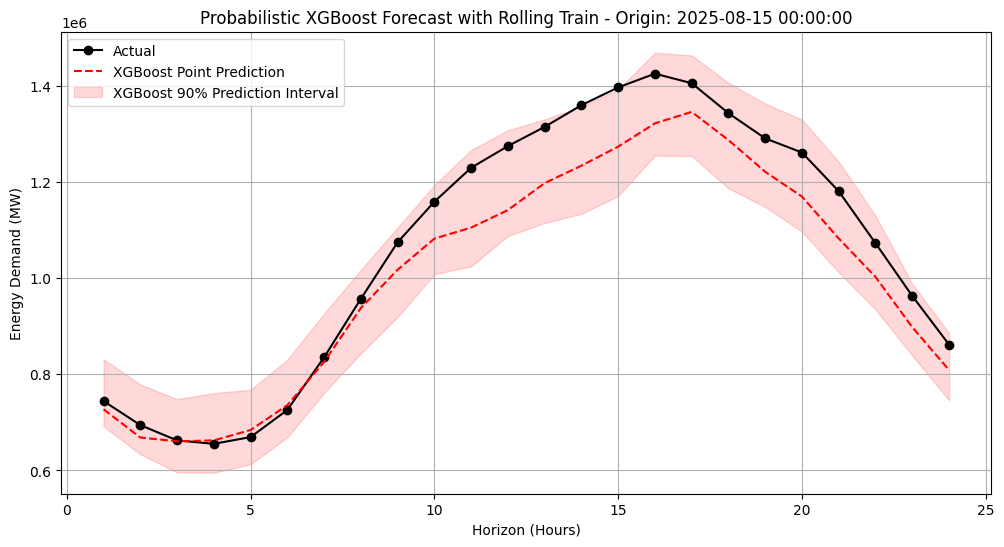

In [7]:
sample_origin = '2025-08-15 00:00:00'
origin_ts = pd.Timestamp(sample_origin)
origins = aug_df[aug_df.index.hour == 0].index
sample_idx = list(origins).index(origin_ts)

act_sample = results['August 2025'][0][sample_idx]
wea_preds = results['August 2025'][1][sample_idx]
wea_lowers = results['August 2025'][2][sample_idx]
wea_uppers = results['August 2025'][3][sample_idx]

plt.figure(figsize=(12, 6))
plt.plot(range(1, 25), act_sample, label='Actual', marker='o', color='black')
plt.plot(range(1, 25), wea_preds, label='XGBoost Point Prediction', linestyle='--', color='red')
plt.fill_between(range(1, 25), wea_lowers, wea_uppers, color='red', alpha=0.15, label='XGBoost 90% Prediction Interval')
plt.title(f"Probabilistic XGBoost Forecast with Rolling Train - Origin: {sample_origin}")
plt.xlabel('Horizon (Hours)')
plt.ylabel('Energy Demand (MW)')
plt.legend()
plt.grid(True)
plt.show()